# Hemispherical asymmetry $A_\mathrm{LV}$

In [1]:
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.mlab as mlab
import matplotlib.colors as mcolors
from matplotlib import cm
import numpy as np
import healpy as hp
import pylab as pl
import math
import sys
sys.path.insert(1, '../../scripts')
import CMBanom
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Parameters
load_stats_from_cluster = True
Nside_in                = 128
Nside_out               = 16
save_stats              = True

# Settings for ALV
theta_deg         = 8
frac_to_be_masked = 0.1

if load_stats_from_cluster: Nsims = 100000
else:                       Nsims = 1000

In [3]:
# Directories
sims_dir  = "../../data/sims/"
stats_dir = "../../data/stats/"
real_dir  = "../../data/real/"
masks_dir = "../../data/masks/"

# Planck maps
names_Planck  = ["cleaned_70GHz_v9_nside_128",     "cleaned_94GHz_v9_nside_128", "cleaned_100GHz_v9_nside_128", "cleaned_143GHz_v9_nside_128",   "commander_nside_128",   "nilc_nside_128",   "sevem_nside_128",   "smica_nside_128"]
labels_Planck = [      r"$70\, \mathrm{GHz}$",           r"$94\, \mathrm{GHz}$",       r"$100\, \mathrm{GHz}$",       r"$143\, \mathrm{GHz}$", r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$"]
colors_Planck = ["tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [      "-",    "-",     "-",     "-",      "--",      "--",     "--",    "--"]
Nmaps = len(names_Planck)
index_Planck  = 4
index_Hayley  = 2

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{1\%\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]

markers     = ["s", "d", "o"]

if Nside_in ==  16: mask_files = ["stdv_mask_1percent_cutoff_0.9_nside_16.fits", "com_mask_cutoff_0.9_nside_16.fits"]
if Nside_in == 128: mask_files = ["1percent_mask_v9.fits",                      "com_mask_cutoff_0.9_nside_128.fits"]
    
Nmasks = len(names_mask)

In [4]:
Npix_in  = hp.nside2npix(Nside_in)
Npix_out = hp.nside2npix(Nside_out)

In [5]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}
prop = {'family': 'Helvetica', 'size': 20}

In [6]:
masks = CMBanom.read_masks(masks_dir, mask_files, Nside_in)
masks_nan = np.where(np.array([mask for mask in masks])==0, np.NaN, 1)

In [7]:
# Read in maps (in muK)
maps_Planck = [hp.read_map(real_dir+"map_"+names_Planck[n]+".fits") for n in range(Nmaps)]
if Nside_in != 128: maps_Planck = np.array([CMBanom.downgrade_map(maps_Planck[n], Nside_in) for n in range(Nmaps)])

# Compute pixel lists and LV mask

In [8]:
pixlists = [CMBanom.get_pixlist(theta_deg, mask, Nside_in, Nside_out) for mask in masks]

In [9]:
lvmasks = np.array([CMBanom.get_lvmask(pixlists[m], theta_deg, frac_to_be_masked, Nside_in, Nside_out) for m in range(Nmasks)])
lvmasks_nan = np.array([np.where(lvmasks[m]==1., 1., np.nan) for m in range(Nmasks)])

# Compute LV maps and $A_\mathrm{LV}$

In [10]:
if load_stats_from_cluster:
    mean_lvmaps = [hp.read_map(f"{stats_dir}meanlvmap_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
    var_lvmaps  = [hp.read_map(f"{stats_dir}varlvmap_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
    ALVs_sims  = np.array([np.loadtxt(stats_dir+f"ALV_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
else:
    maps_sims  = np.array([hp.read_map(sims_dir+f"map__{n}.fits") for n in range(Nsims)])
    if Nside_in != 128: maps_sims = np.array([CMBanom.downgrade_map(map, Nside_in) for map in maps_sims])

    lvmaps_sims = np.array([[CMBanom.get_lvmap(maps_sims[n], masks[m], pixlists[m], Nside_out) for n in range(Nsims)] for m in range(Nmasks)])
    mean_lvmaps = np.array([CMBanom.get_meanlvmap(lvmaps_sims[m], lvmasks[m]) for m in range(Nmasks)])
    var_lvmaps  = np.array([CMBanom.get_varlvmap(lvmaps_sims[m], lvmasks[m], mean_lvmaps[m]) for m in range(Nmasks)])
    ALVs_sims   = np.array([[CMBanom.ALV_vec(lvmaps_sims[m][n], lvmasks[m], mean_lvmaps[m], var_lvmaps[m])[0] for n in range(Nsims)] for m in range(Nmasks)])

In [11]:
lvmaps_Planck  = np.array([[CMBanom.get_lvmap(maps_Planck[n], masks[m], pixlists[m], Nside_out) for n in range(Nmaps)] for m in range(Nmasks)])
ALVs_Planck    = np.array([[CMBanom.ALV_vec(lvmaps_Planck[m][n], lvmasks[m], mean_lvmaps[m], var_lvmaps[m])[0] for n in range(Nmaps)] for m in range(Nmasks)])
dipvecs_Planck = np.array([[CMBanom.ALV_vec(lvmaps_Planck[m][n], lvmasks[m], mean_lvmaps[m], var_lvmaps[m])[1] for n in range(Nmaps)] for m in range(Nmasks)])

# Save stats to file 

In [12]:
if save_stats: np.save(stats_dir+"ALV_real", ALVs_Planck)

# Plot LV maps

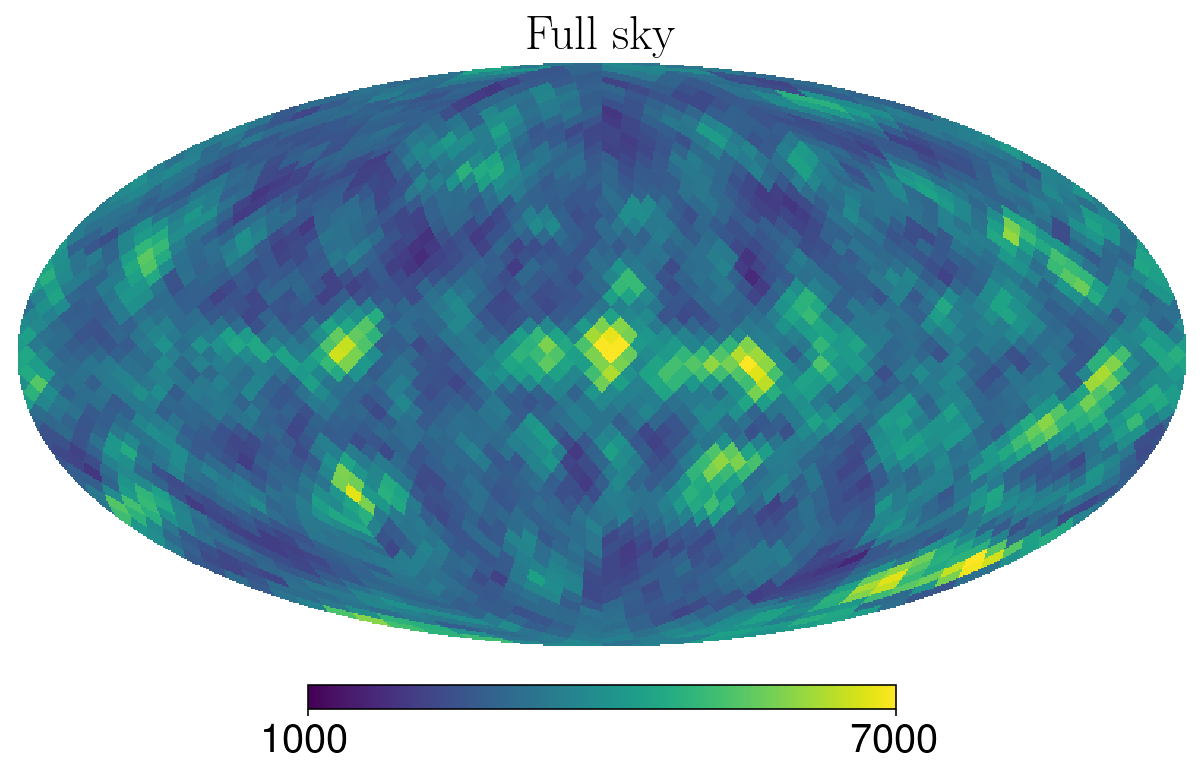

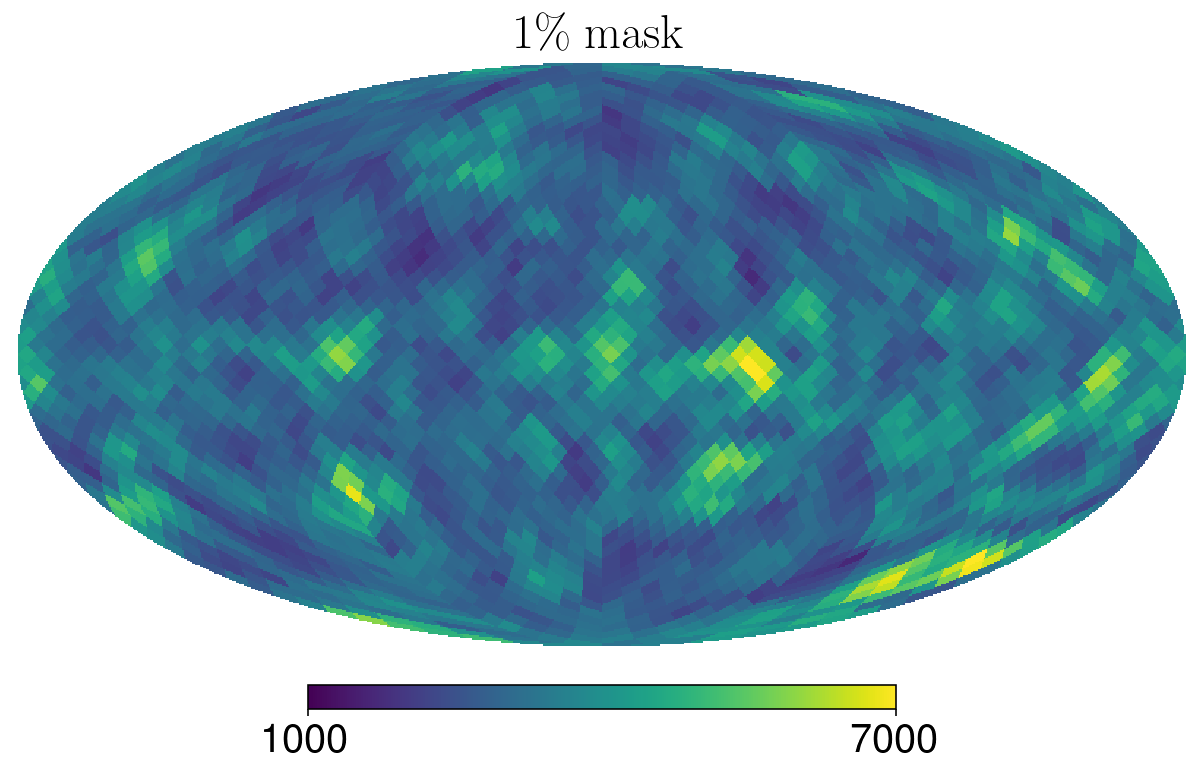

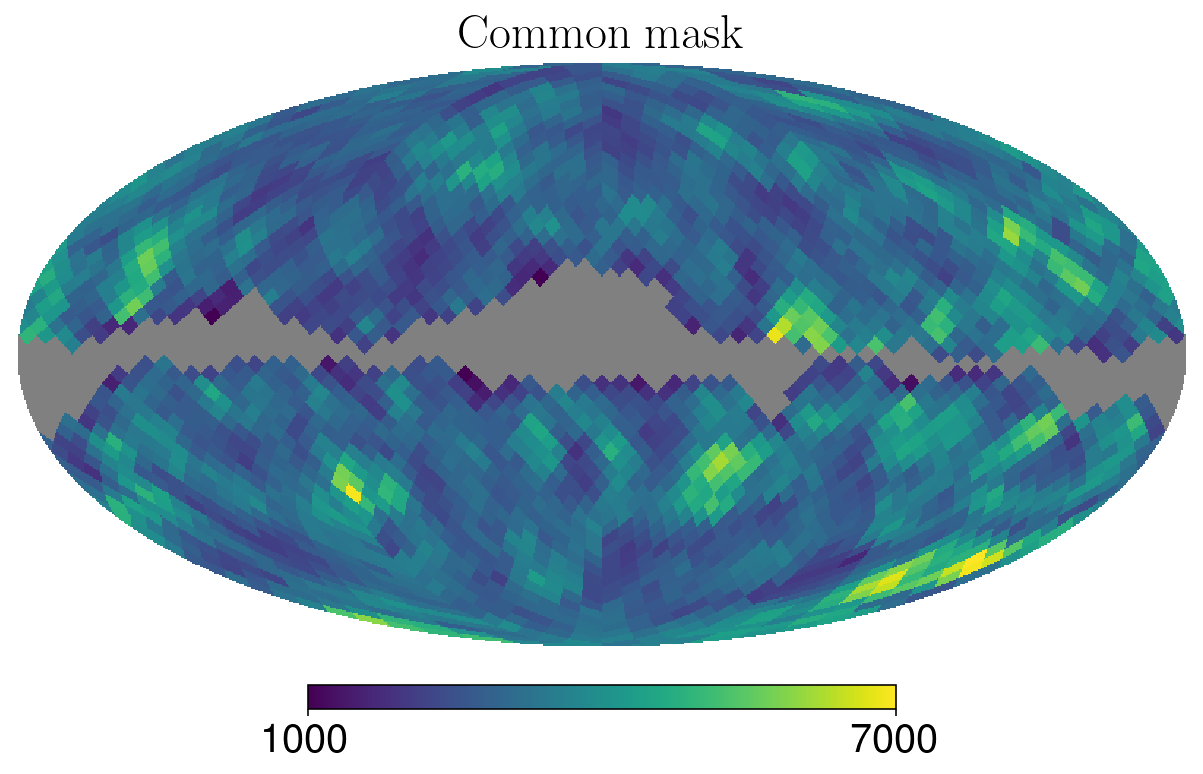

In [13]:
for m in range(Nmasks): hp.mollview(lvmaps_Planck[m][index_Hayley]*lvmasks_nan[m], title=labels_mask[m], min=1000, max=7000)

# Plot histograms

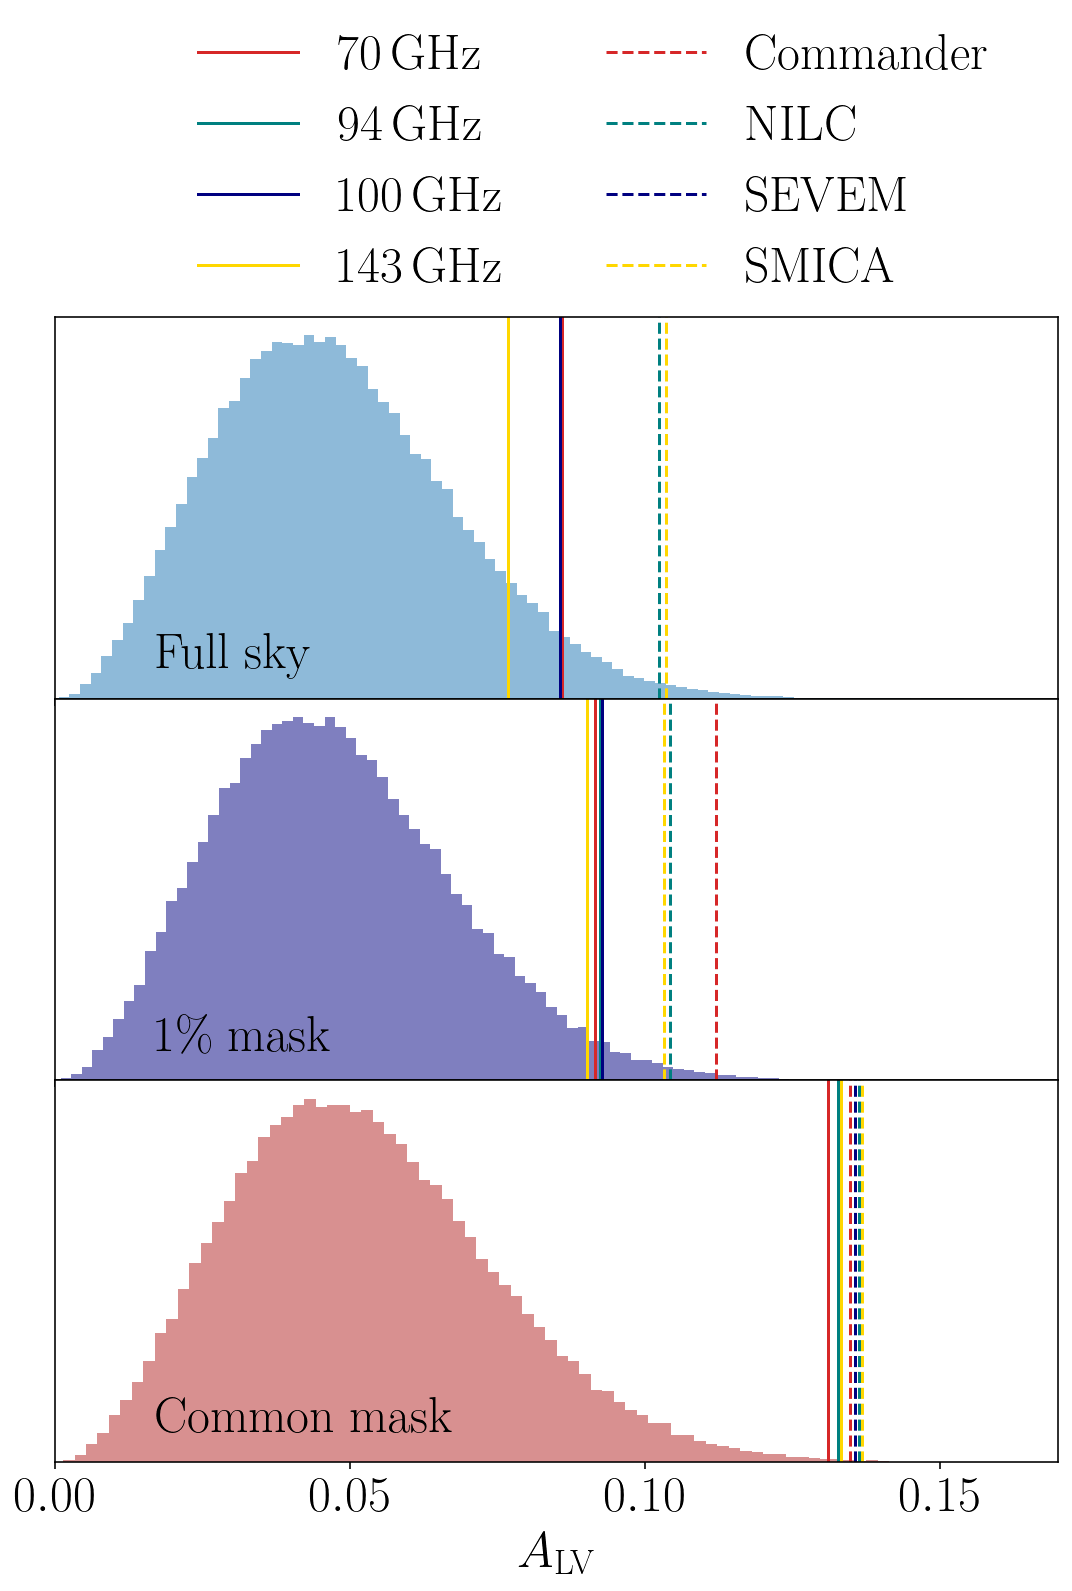

In [14]:
plt.rc('font',**{'family':'Helvetica','size':25})
fig, axs = plt.subplots(Nmasks, 1, figsize=(8, 10), sharex=True, gridspec_kw={'hspace': 0})

for m in range(Nmasks):
    for n in range(Nmaps): 
        axs[m].axvline(ALVs_Planck[m][n], label=labels_Planck[n], color=colors_Planck[n], ls=lss_Planck[n])
    axs[m].hist(ALVs_sims[m], bins=100, alpha=0.5, color=colors_mask[m])
    
    axs[m].set_xlim(0, 0.17)
    axs[m].tick_params(axis='y', which='both', left=False, labelleft=False) 
    axs[m].text(0.1, 0.05, labels_mask[m], horizontalalignment='left', verticalalignment='bottom', transform=axs[m].transAxes)

axs[-1].set_xlabel(r"$A_\mathrm{LV}$")
fig.legend(labels_Planck, loc='upper center', ncol=2, bbox_to_anchor=(0.55, 1.17), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

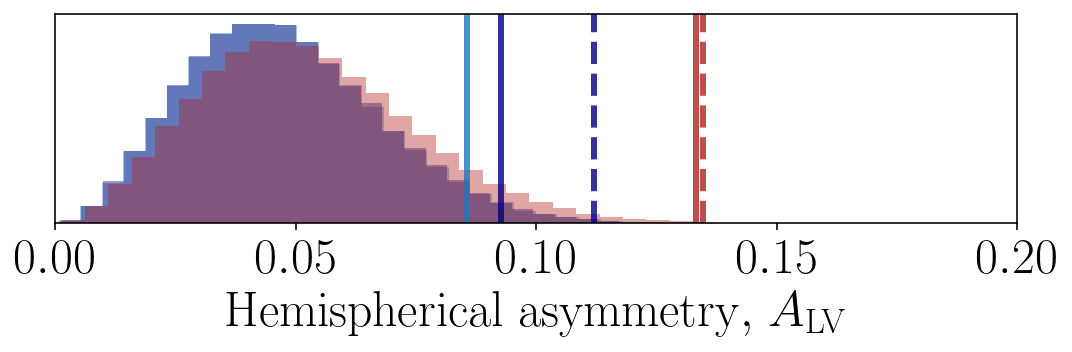

In [15]:
fig = plt.figure(figsize=(8, 3))
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(ALVs_sims[m], bins=40, alpha=0.4, density=True, color=colors_mask[m])
    plt.axvline(ALVs_Planck[m][index_Hayley], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    plt.axvline(ALVs_Planck[m][index_Planck], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
plt.xlim(0, 0.2)
plt.xlabel(r"$\mathrm{Hemispherical\ asymmetry,}\ A_\mathrm{LV}$")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
#plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [16]:
pvals = [[CMBanom.pval_higher(ALVs_Planck[m][n], ALVs_sims[m]) for n in range(Nmaps)] for m in range(Nmasks)]

In [17]:
for m in range(Nmasks):
    print("-----------")
    print(names_mask[m])
    for n in range(Nmaps):
        print(f"ALV = {ALVs_Planck[m][n]:.2f}, p-value: {100*pvals[m][n]:.2f}% ({names_Planck[n]})")

-----------
fullsky
ALV = 0.09, p-value: 3.99% (cleaned_70GHz_v9_nside_128)
ALV = 0.21, p-value: 0.00% (cleaned_94GHz_v9_nside_128)
ALV = 0.09, p-value: 4.13% (cleaned_100GHz_v9_nside_128)
ALV = 0.08, p-value: 8.62% (cleaned_143GHz_v9_nside_128)
ALV = 0.30, p-value: 0.00% (commander_nside_128)
ALV = 0.10, p-value: 0.86% (nilc_nside_128)
ALV = 0.61, p-value: 0.00% (sevem_nside_128)
ALV = 0.10, p-value: 0.77% (smica_nside_128)
-----------
stdmask
ALV = 0.09, p-value: 2.42% (cleaned_70GHz_v9_nside_128)
ALV = 0.09, p-value: 2.26% (cleaned_94GHz_v9_nside_128)
ALV = 0.09, p-value: 2.18% (cleaned_100GHz_v9_nside_128)
ALV = 0.09, p-value: 2.77% (cleaned_143GHz_v9_nside_128)
ALV = 0.11, p-value: 0.29% (commander_nside_128)
ALV = 0.10, p-value: 0.71% (nilc_nside_128)
ALV = 0.19, p-value: 0.00% (sevem_nside_128)
ALV = 0.10, p-value: 0.78% (smica_nside_128)
-----------
commask
ALV = 0.13, p-value: 0.16% (cleaned_70GHz_v9_nside_128)
ALV = 0.13, p-value: 0.14% (cleaned_94GHz_v9_nside_128)
ALV = 0.13

# Plot directions of LV dipole

In [18]:
# Compute normalized LV maps for plotting purposes
meanvar_lvmap = np.nanmean(var_lvmaps*lvmasks_nan)
normlvmaps_Planck = np.array([[(meanvar_lvmap/var_lvmaps[m])*(lvmaps_Planck[m][n] - mean_lvmaps[m])/mean_lvmaps[m] for n in range(Nmaps)] for m in range(Nmasks)])

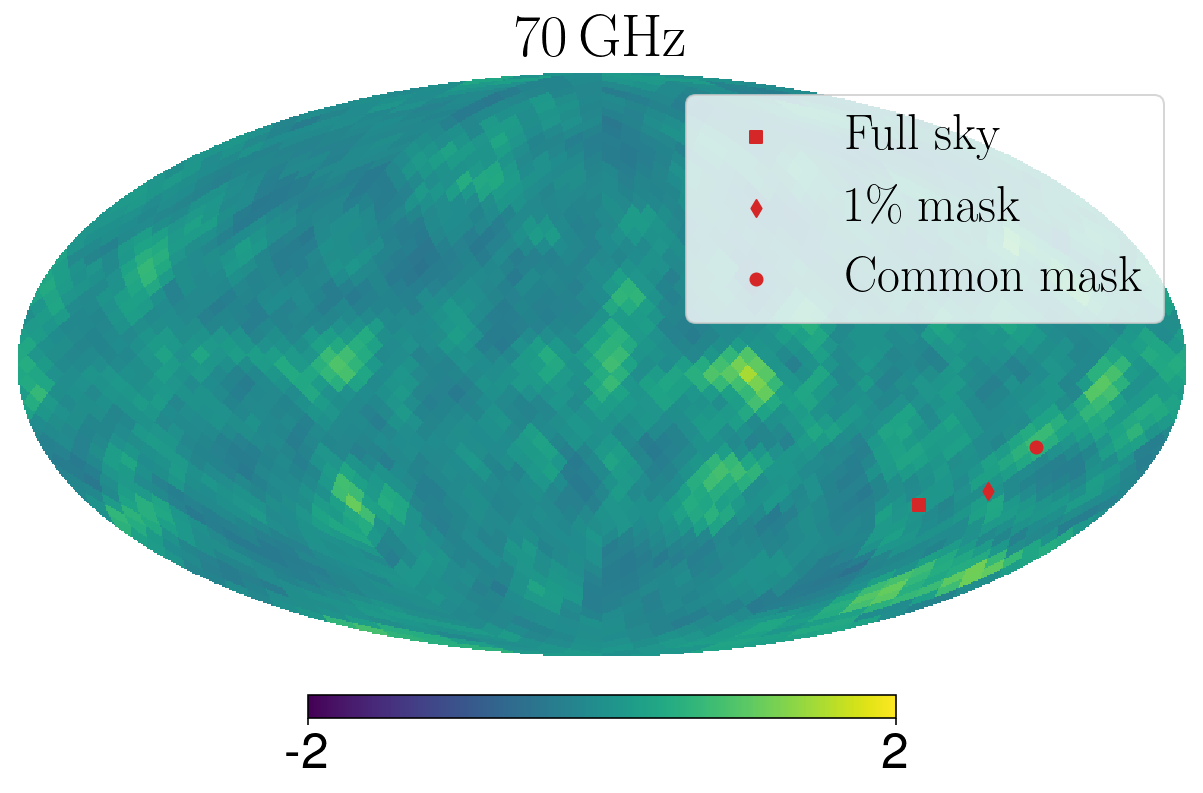

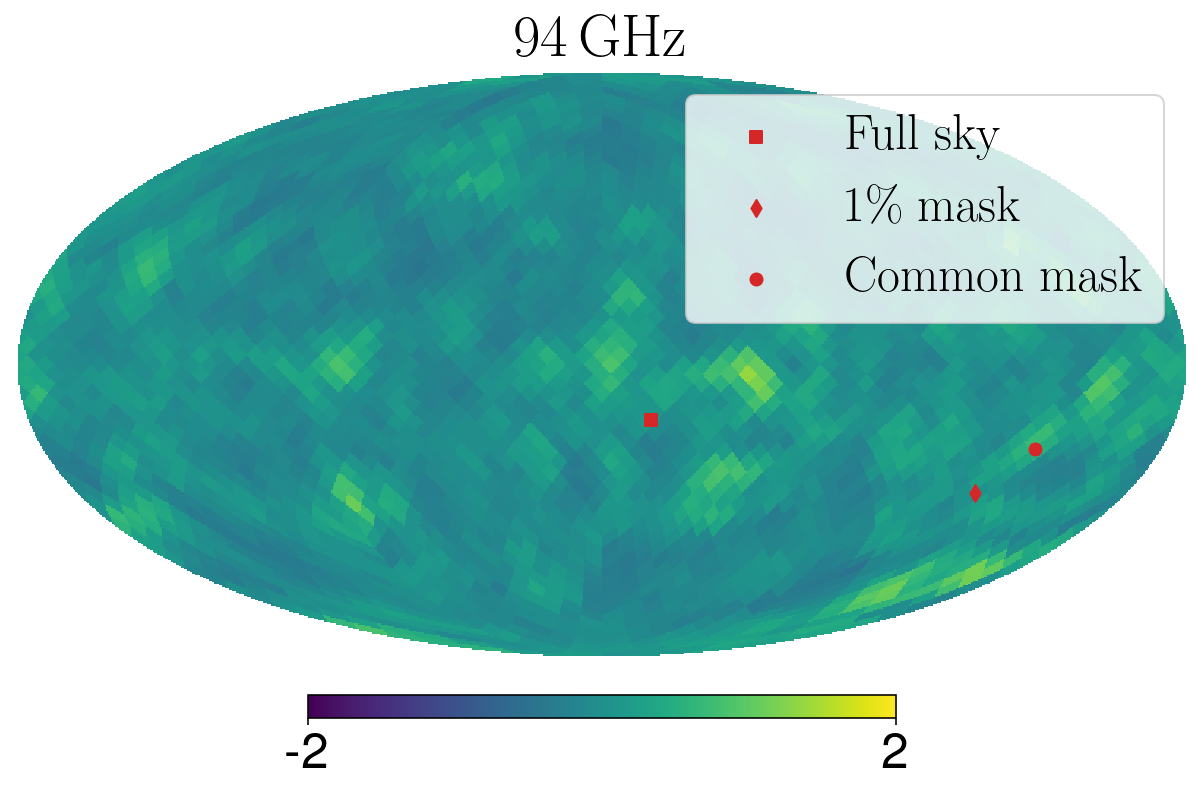

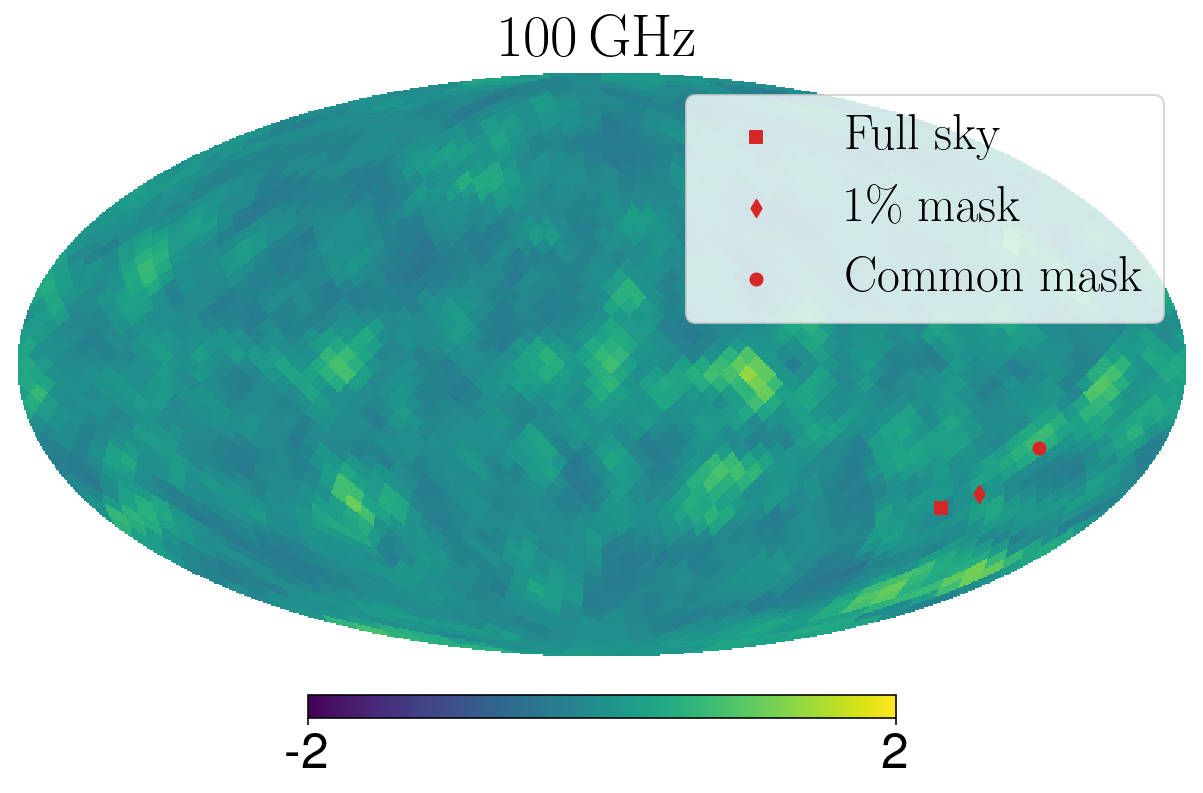

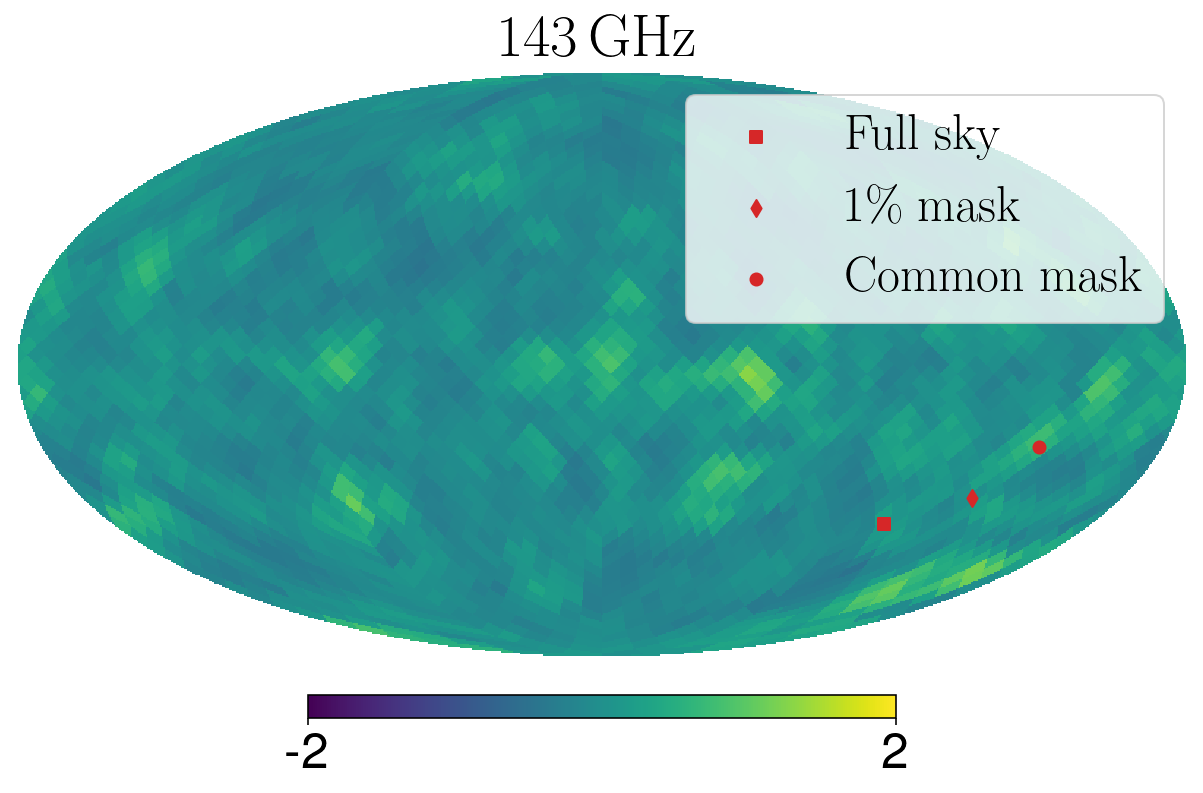

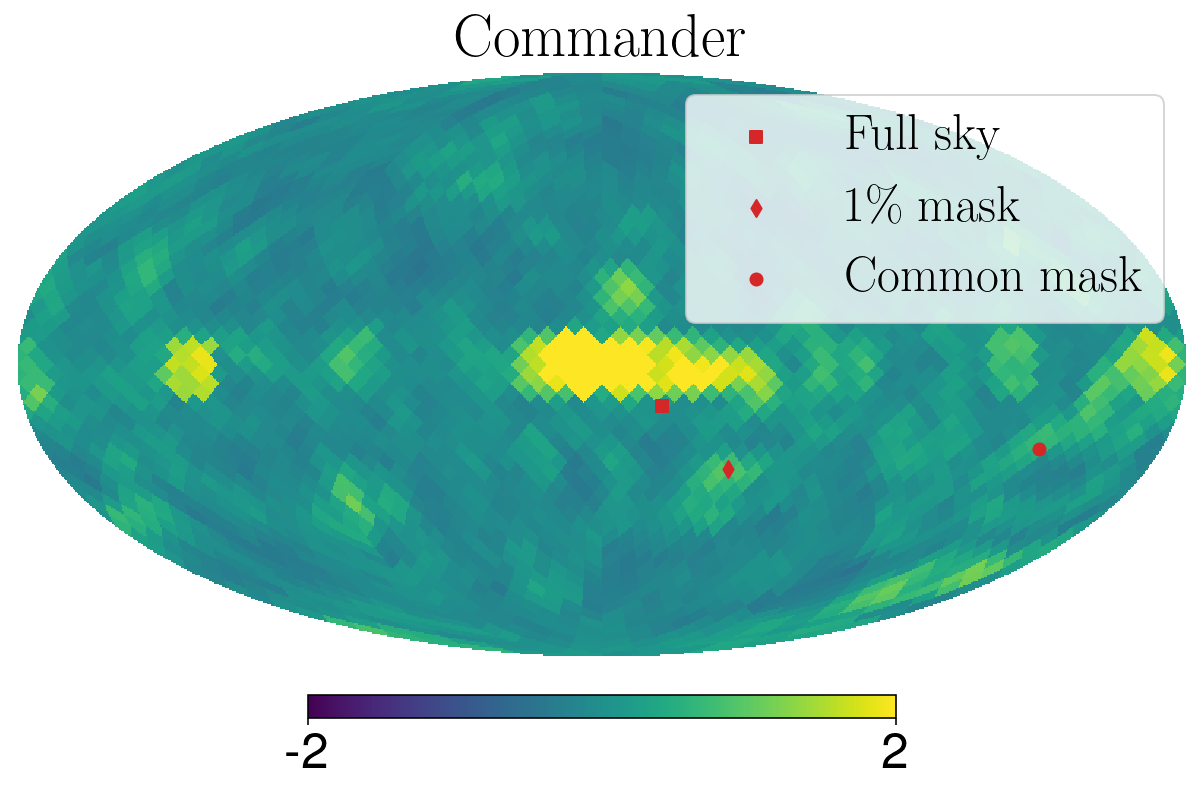

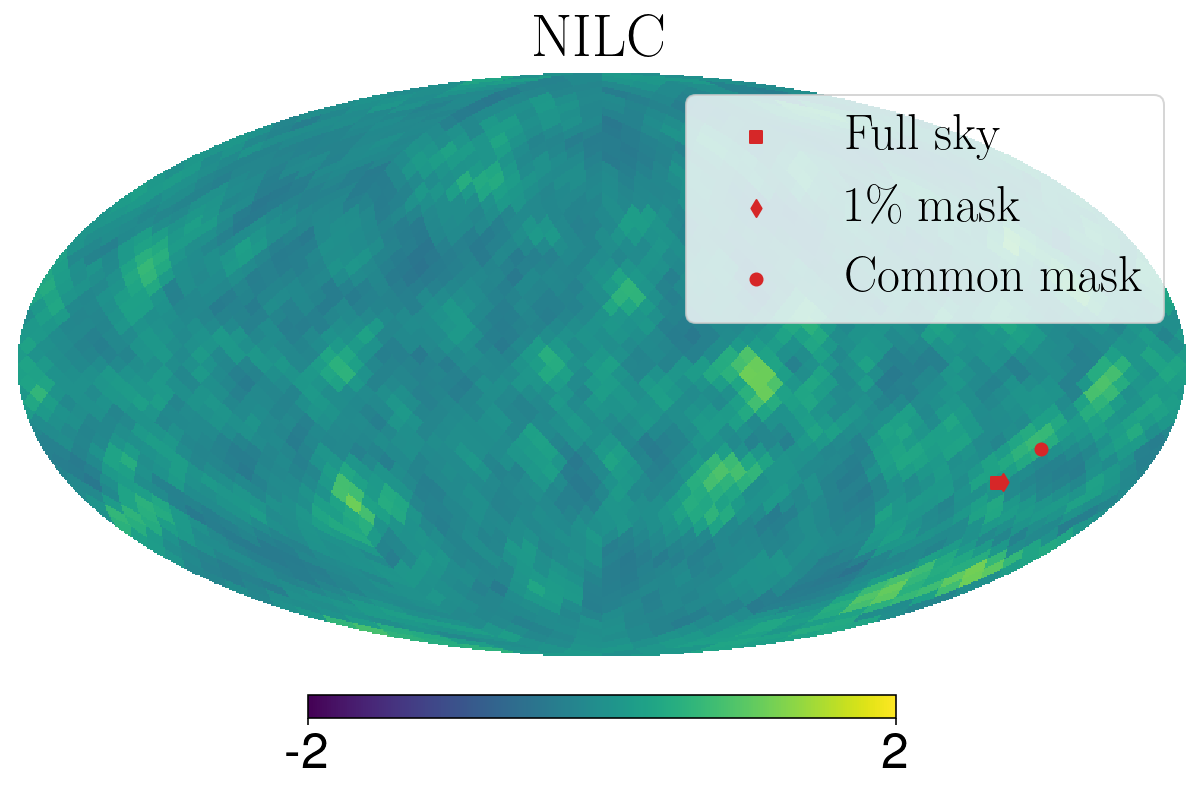

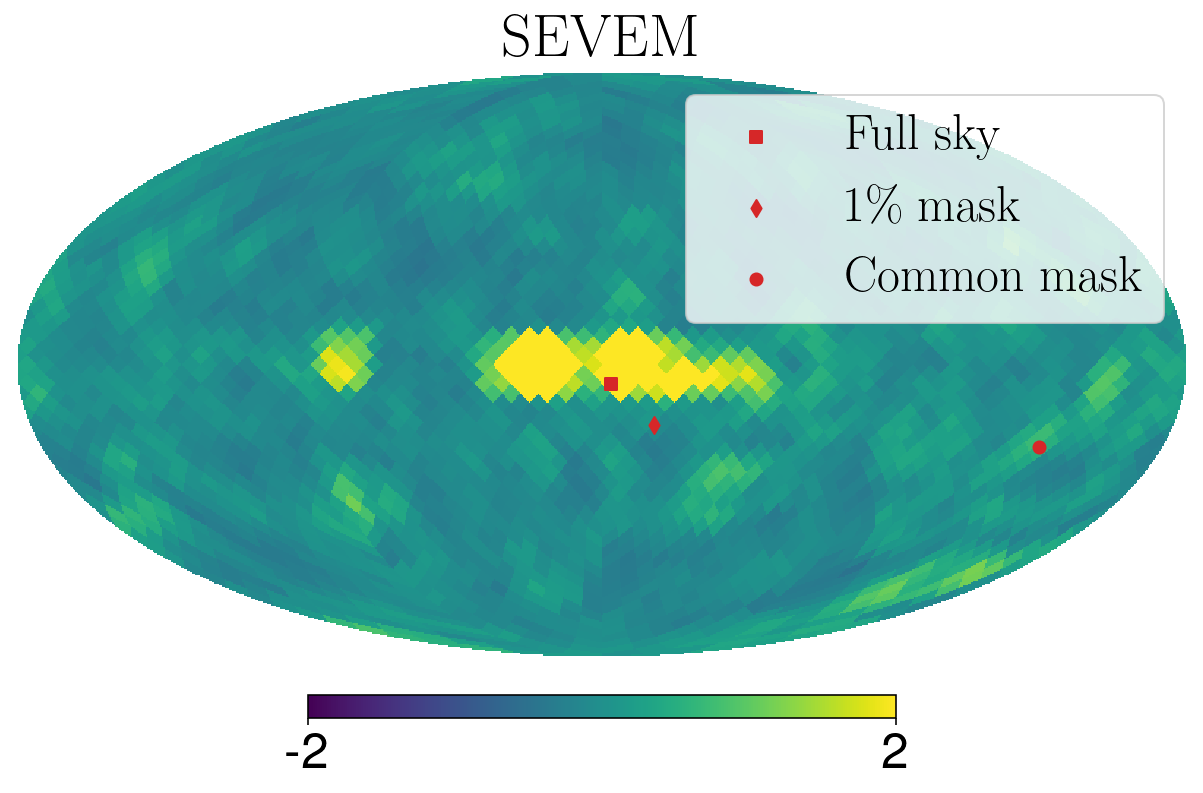

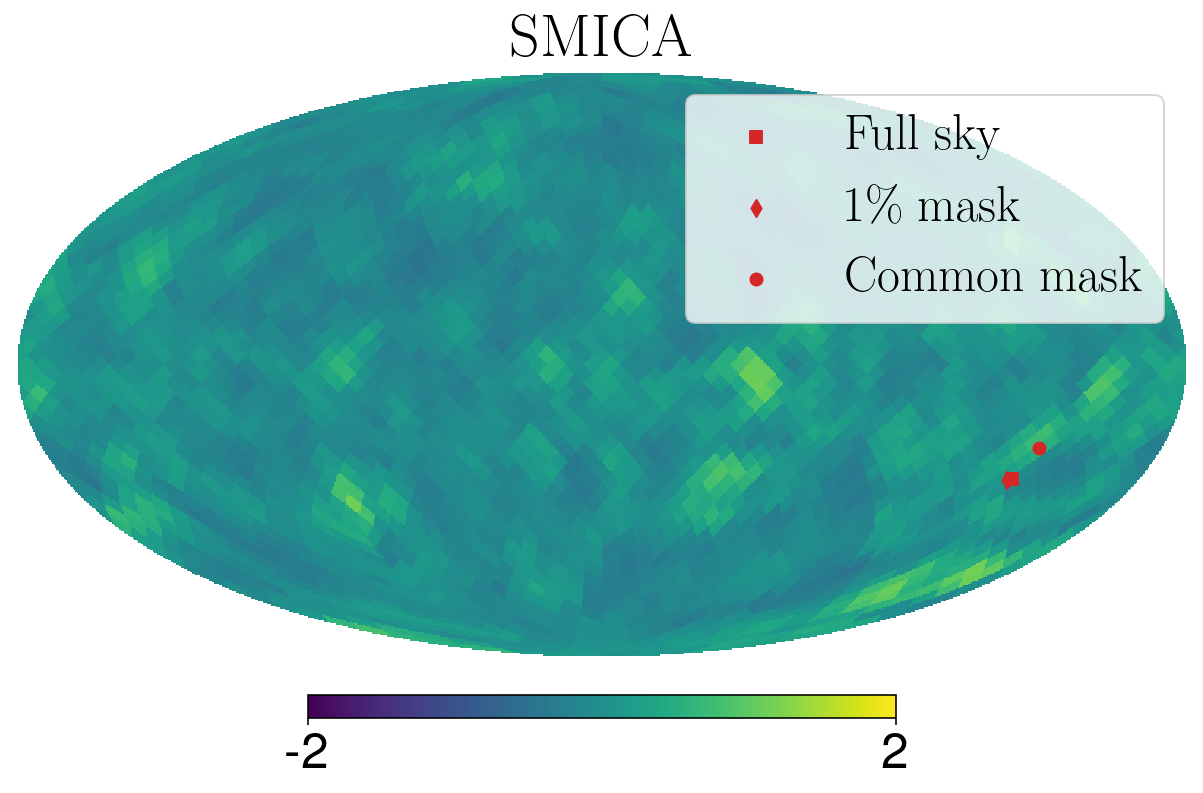

In [19]:
for n in range(Nmaps):
    m = 1
    hp.mollview(normlvmaps_Planck[m][n]*lvmasks[m], title=labels_Planck[n], min=-2, max=2)
    for m in range(Nmasks):
        theta, phi = hp.vec2ang(dipvecs_Planck[m][n])
        hp.projscatter(theta, phi, color="tab:red", marker=markers[m], label=labels_mask[m])
    plt.legend()

<Figure size 432x288 with 0 Axes>

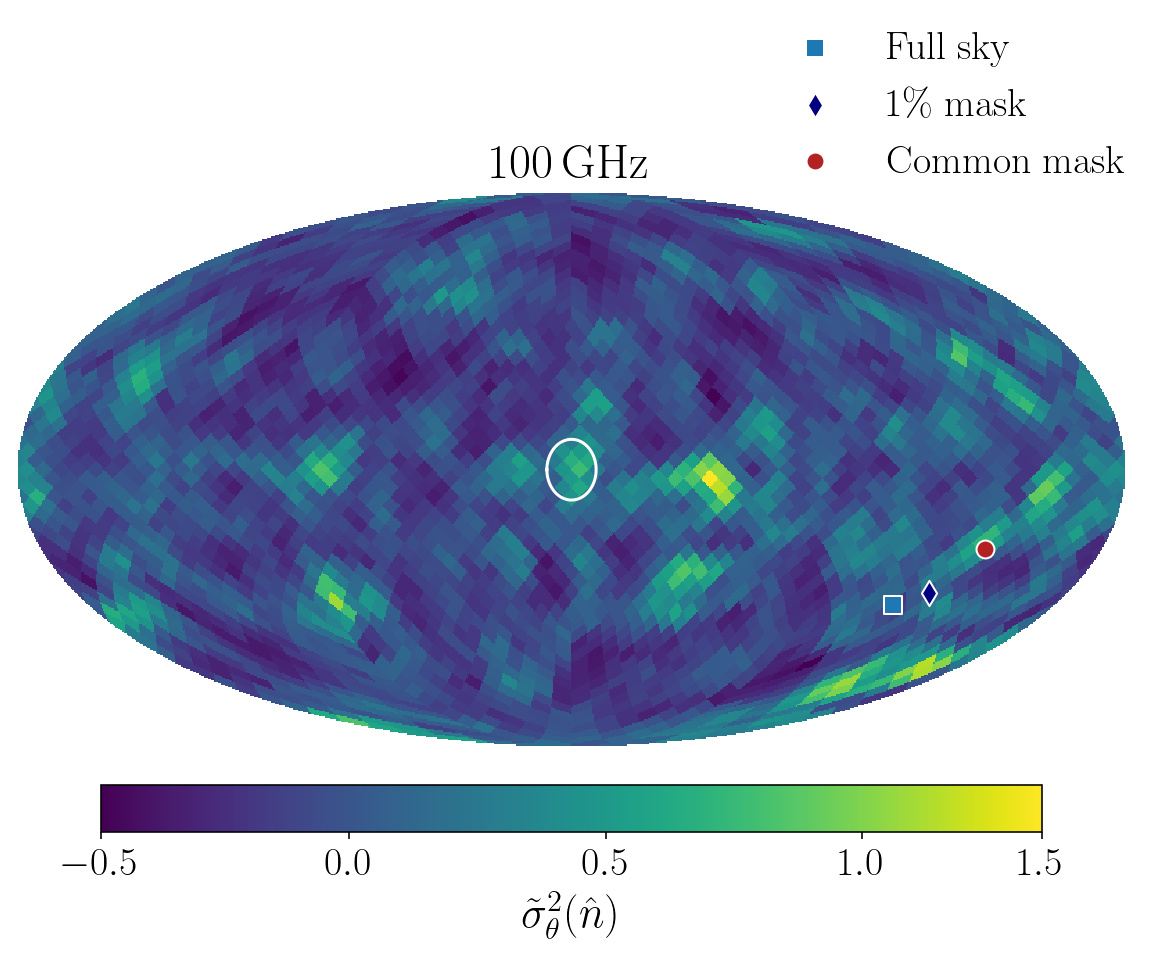

In [20]:
# Plot 100GHz for paper
plt.rc('font', **{'family': 'Helvetica', 'size': 20})
m = 1
n = index_Hayley
fig = plt.figure()
map_data = normlvmaps_Planck[m][n] * lvmasks[m]
hp.mollview(map_data, title=labels_Planck[n], cbar=False)

# Define the center of the circle in galactic coordinates
galactic_center_lon = 0  # Galactic longitude
galactic_center_lat = 0  # Galactic latitude

# Define the radius of the circle in degrees
radius = 8

# Create a circle around the galactic center
theta = np.linspace(0, 2 * np.pi, 100)
circle_lon = galactic_center_lon + radius * np.cos(theta)
circle_lat = galactic_center_lat + radius * np.sin(theta)

# Convert the circle's longitude and latitude to theta and phi
circle_theta = np.radians(90 - circle_lat)  # Convert latitude to colatitude
circle_phi = np.radians(circle_lon)  # Convert longitude to radians

# Plot the circle
hp.projplot(circle_theta, circle_phi, lonlat=False, linewidth=1.5, color="white")

# Plot dipole directions
for m in range(Nmasks):
    theta, phi = hp.vec2ang(dipvecs_Planck[m][n])
    hp.projscatter(theta, phi, marker=markers[m], label=labels_mask[m], color=colors_mask[m], edgecolor="white", s=80)
plt.legend(loc="upper left", bbox_to_anchor=(0.65, 1.35), frameon=False)

# Retrieve the current axis and the mappable object
ax = plt.gca()
im = ax.get_images()[0]  # Get the first image object

# Add a colorbar with custom fontsize
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label(r"$\tilde{\sigma}_\theta^2(\hat{n})$", fontsize=22)
cbar.ax.tick_params(labelsize=20)

plt.savefig("Norm_LVmap_100GHz.pdf", format="PDF", bbox_inches="tight")
plt.show()

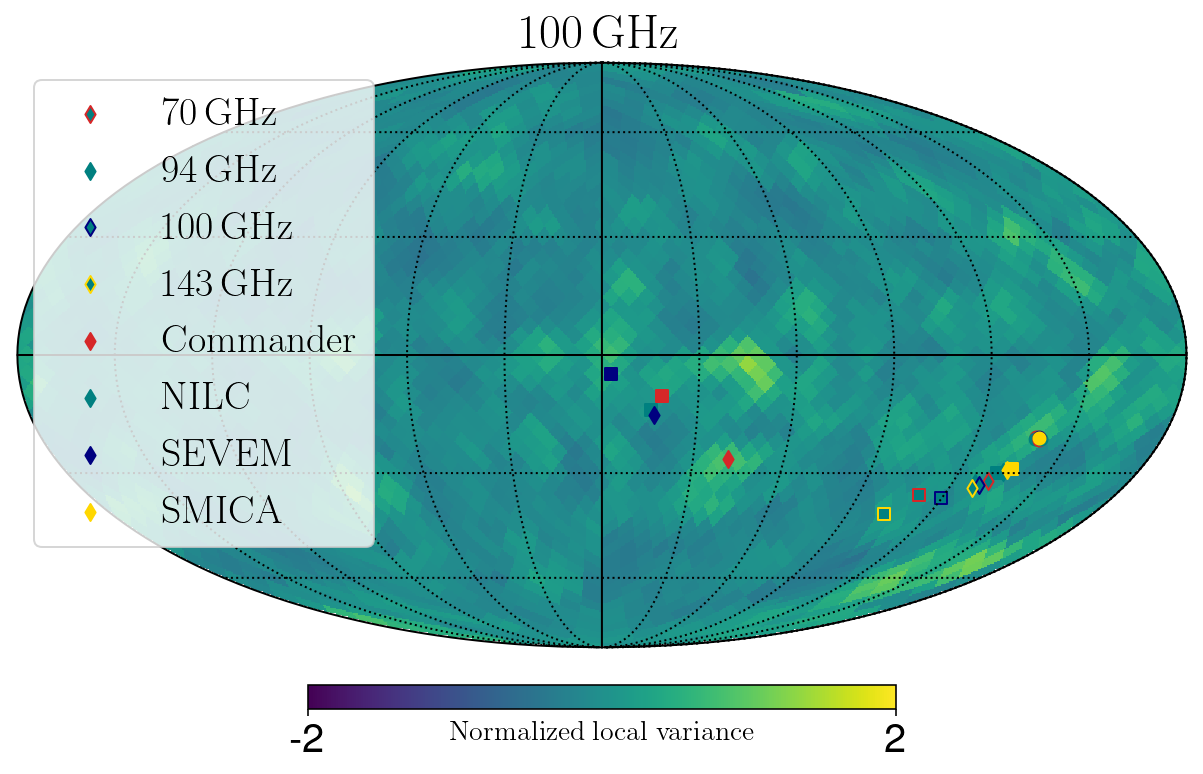

In [21]:
m = 1
hp.mollview(normlvmaps_Planck[m][index_Hayley]*lvmasks_nan[m], min=-2, max=2, title=labels_Planck[index_Hayley], unit=r"$\mathrm{Normalized\ local\ variance}$")
hp.graticule()
for m in range(Nmasks):
    for n in range(Nmaps):
        theta, phi = hp.vec2ang(dipvecs_Planck[m][n])
        if (m==1): label = labels_Planck[n];
        else: label=None
        if n>3: hp.projscatter(theta, phi, marker=markers[m], color=colors_Planck[n], label=label)
        else:   hp.projscatter(theta, phi, marker=markers[m], color="teal", edgecolor=colors_Planck[n], label=label)
plt.legend()
plt.show()

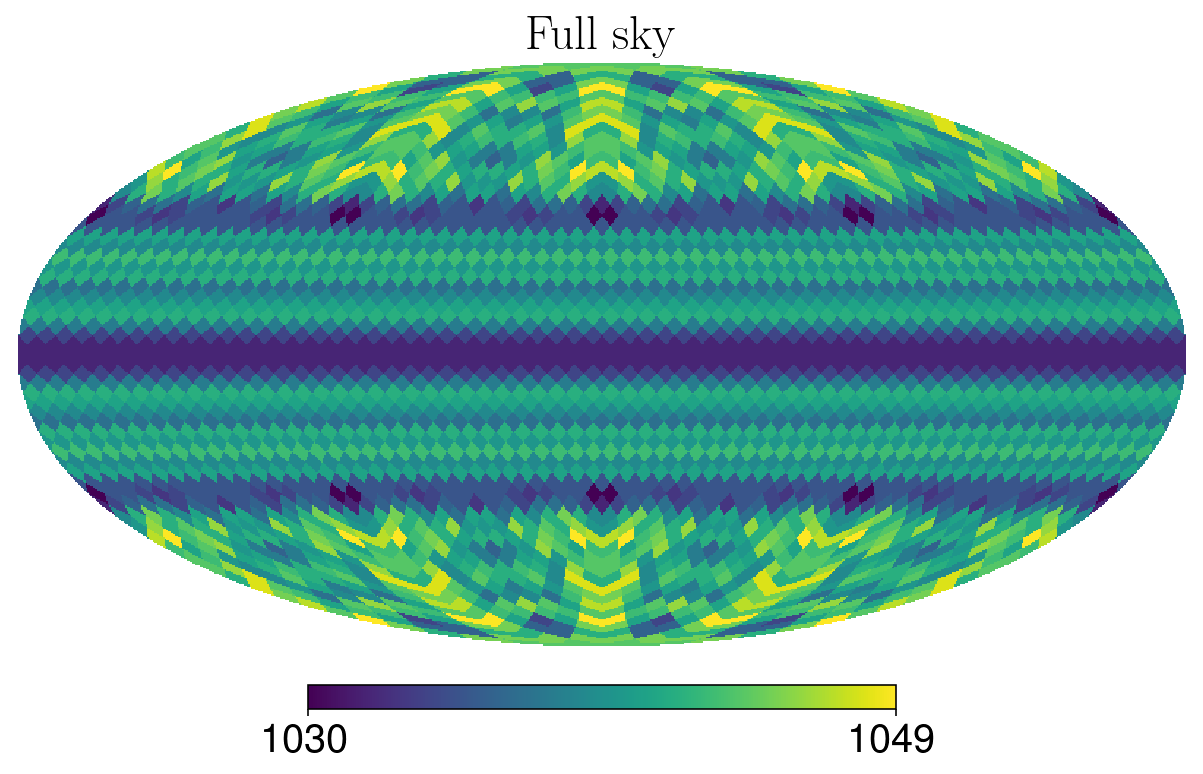

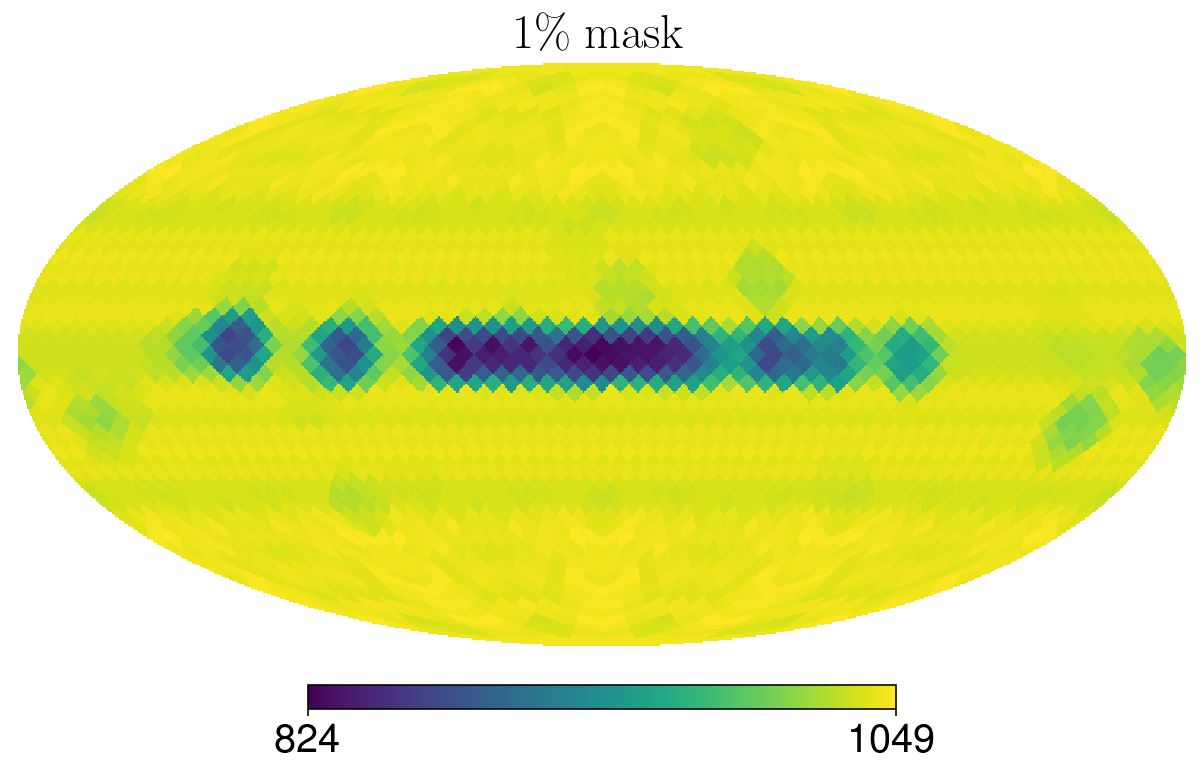

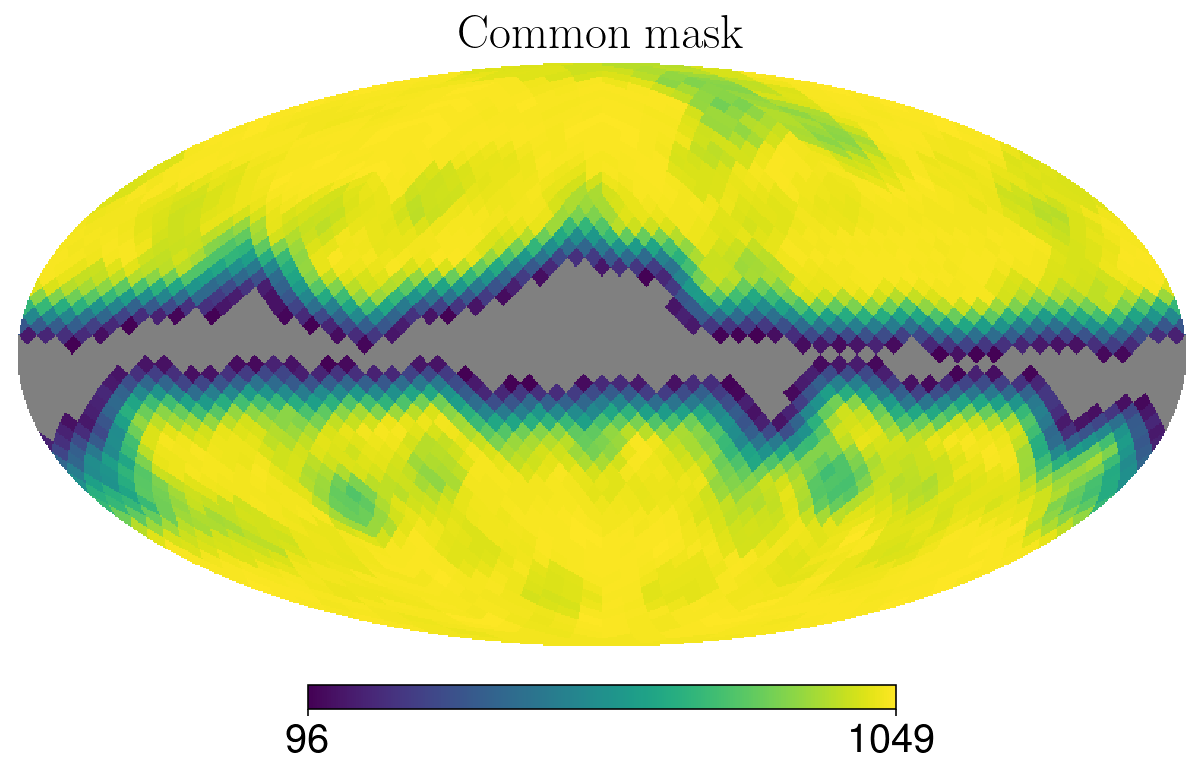

In [22]:
lens_pixlist = np.array([[len(list) for list in pixlists[m]] for m in range(Nmasks)])
for m in range(Nmasks): hp.mollview(lens_pixlist[m]*lvmasks_nan[m], title=labels_mask[m])